In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import mysql.connector 
import numpy as np 

In [2]:
db = mysql.connector.connect(host = "localhost",
                             username ="root",
                             password ="kushal@123",
                             database ="ecommerce")
cur = db.cursor()

 # List all unique cities where customers are located.

In [3]:
query = """select distinct upper(customer_city) from customers"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data , columns = ["Customer_City"])
df.head()

,Customer_City
0,FRANCA
1,SAO BERNARDO DO CAMPO
2,SAO PAULO
3,MOGI DAS CRUZES
4,CAMPINAS


# Count the number of orders placed in 2017.

In [4]:
query = """ select count(order_id) from orders where year(order_purchase_timestamp) = 2017 """

cur.execute(query)

data = cur.fetchall()

"total orders placed in 2017 are " , data[0][0]

('total orders placed in 2017 are ', 45101)

# Find the total sales per category.

In [5]:
query = """ select upper(products.product_category) as category,
round(sum(payments.payment_value),2) as sales 
from products join order_items
on products.product_id = order_items.product_id
join payments 
on payments.order_id = order_items.order_id
group by category 
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data , columns = ["Category", "Sales"])
df

,Category,Sales
0,PERFUMERY,506738.66
1,FURNITURE DECORATION,1430176.39
2,TELEPHONY,486882.05
3,BED TABLE BATH,1712553.67
4,AUTOMOTIVE,852294.33
...,...,...
69,CDS MUSIC DVDS,1199.43
70,LA CUISINE,2913.53
71,FASHION CHILDREN'S CLOTHING,785.67
72,PC GAMER,2174.43


# Calculate the percentage of orders that were paid in installments.

In [6]:
query = """ select (sum(case when payment_installments >=1 then 1
else 0 end))/count(*)*100 from payments 
"""

cur.execute(query)

data = cur.fetchall()

"the percentage of orders that were paid in installments is ",data[0][0]

('the percentage of orders that were paid in installments is ',
 Decimal('99.9981'))

# Count the number of customers from each state. 


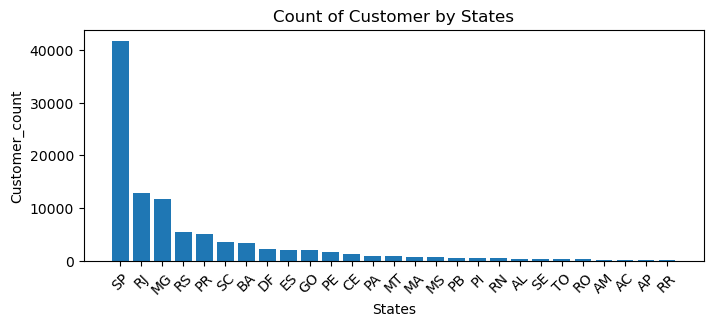

In [8]:
query = """ select customer_state , count(customer_id)
from customers group by customer_state
"""

cur.execute(query)

data = cur.fetchall()
df= pd.DataFrame(data, columns = ["state", "customer_count"])
df = df.sort_values(by ="customer_count", ascending= False)
plt.figure(figsize = (8,3))
plt.bar(df["state"], df["customer_count"])
plt.xticks(rotation =45)
plt.xlabel("States")
plt.ylabel("Customer_count")
plt.title("Count of Customer by States")
plt.show()

# Calculate the number of orders per month in 2018.

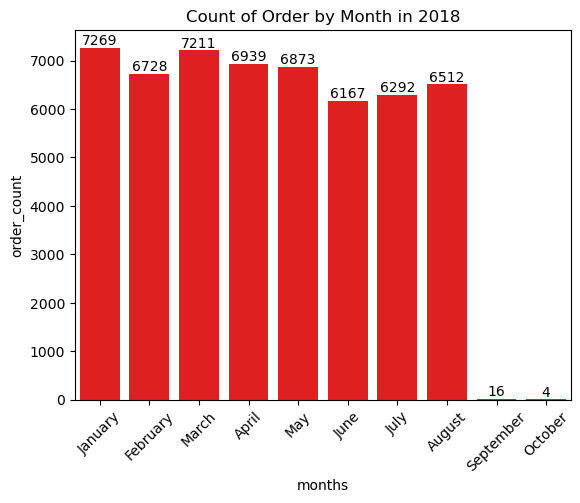

<Figure size 800x300 with 0 Axes>

In [9]:
query = """ select monthname(order_purchase_timestamp) as months, count(order_id)
as order_count from orders where year(order_purchase_timestamp) = 2018
group by months 
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data , columns = ["months","order_count"])
o = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October"]

ax = sns.barplot(x = df["months"], y= df["order_count"],data = df, order = o, color = "red")
plt.title("Count of Order by Month in 2018")
plt.xticks(rotation =45)

plt.figure(figsize = (8,3))

ax.bar_label(ax.containers[0])


plt.show()

# Find the average number of products per order, grouped by customer city.

In [10]:
query = """ with count_per_order as 
(select orders.order_id, orders.customer_id, count(order_items.order_id) as oc
from orders join order_items
on orders.order_id = order_items.order_id
group by orders.order_id, orders.customer_id)

select upper(customers.customer_city), round(avg(count_per_order.oc),2) as average_orders
from customers join count_per_order
on customers.customer_id = count_per_order.customer_id
group by customers.customer_city order by average_orders desc;
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data , columns = ["Customer_City", "Average_Orders"])
df.head(10)

,Customer_City,Average_Orders
0,PADRE CARVALHO,7.00
1,CELSO RAMOS,6.50
2,DATAS,6.00
3,CANDIDO GODOI,6.00
4,MATIAS OLIMPIO,5.00
5,MORRO DE SAO PAULO,4.00
6,TEIXEIRA SOARES,4.00
7,CURRALINHO,4.00
8,CIDELANDIA,4.00
9,PICARRA,4.00


# Calculate the percentage of total revenue contributed by each product category.


In [8]:
query = """select upper(products.product_category) as category,

round(sum(payments.payment_value)/(select sum(payment_value) from payments)*100,2) as sales_persentage
from products join order_items
on products.product_id = order_items.product_id
join payments 
on payments.order_id = order_items.order_id
group by category order by sales_persentage desc """

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data , columns = ["Category", "Persentage Distribution"])
df.head(10)

,Category,Persentage Distribution
0,BED TABLE BATH,10.70
1,HEALTH BEAUTY,10.35
2,COMPUTER ACCESSORIES,9.90
3,FURNITURE DECORATION,8.93
4,WATCHES PRESENT,8.93
5,SPORT LEISURE,8.70
6,HOUSEWARES,6.84
7,AUTOMOTIVE,5.32
8,GARDEN TOOLS,5.24
9,COOL STUFF,4.87


# Identify the correlation between product price and the number of times a product has been purchased.


In [16]:
query = """select products.product_category,
count(order_items.product_id),
round(avg(order_items.price),2)
from products join order_items
on products.product_id = order_items.product_id 
group by products.product_category;"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data , columns = ["Category", "Order_Count", "Price"])
df.head(10)
arr1 = df["Order_Count"]
arr2 = df["Price"]

a = np.corrcoef(arr1,arr2)
print("the correlation between price and number of times a product has been purchased is ", a[0][-1])

the correlation between price and number of times a product has been purchased is  -0.10631514167157562


# Calculate the total revenue generated by each seller, and rank them by revenue.



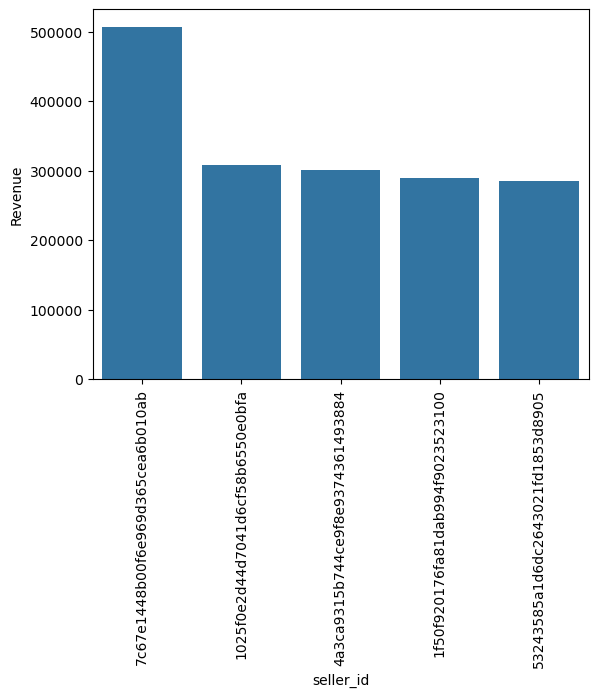

In [35]:
query = """select *, dense_rank() over (order by revenue desc) as rn from 
(select order_items.seller_id, sum(payments.payment_value) as revenue 
from order_items join payments 
on order_items.order_id = payments.order_id
group by order_items.seller_id) as a"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["seller_id", "Revenue", "Rank"])
df = df.head()
sns.barplot(x= "seller_id",y = "Revenue", data = df)
plt.xticks(rotation = 90)
plt.show()

# Calculate the moving average of order values for each customer over their order history.

In [38]:
query = """select customer_id , order_purchase_timestamp, payment, 
avg(payment) over(partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row) as mov_avg
from
(select orders.customer_id, orders.order_purchase_timestamp,
payments.payment_value as payment
from payments join orders 
on payments.order_id = orders.order_id) as a; 
"""

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data)
df 


,0,1,2,3
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.350006
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.010002
...,...,...,...,...
103881,fffecc9f79fd8c764f843e9951b11341,2018-03-29 16:59:26,71.23,27.120001
103882,fffeda5b6d849fbd39689bb92087f431,2018-05-22 13:36:02,63.13,63.130001
103883,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.13,214.130005
103884,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.500000


# Calculate the cumulative sales per month for each year.

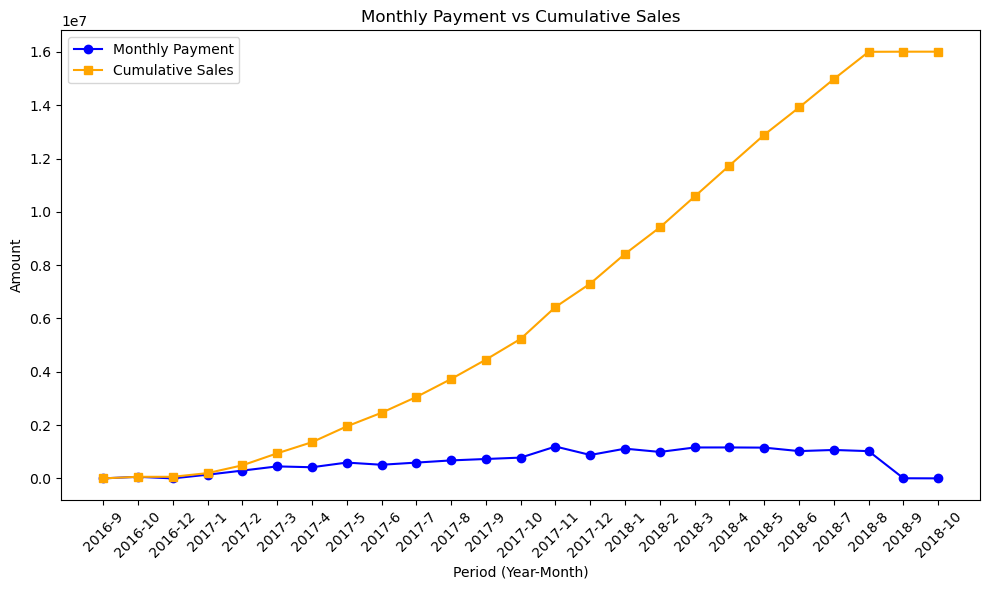

In [27]:
query = """select years, months, payment,sum(payment)
over(order by years, months) Cumulative_sales from
(select year(orders.order_purchase_timestamp) as years,
month(orders.order_purchase_timestamp) as months,
round(sum(payments.payment_value),2) as payment from orders join payments
on payments.order_id = orders.order_id 
group by years,months order by years , months) as a """

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data,columns = ["Years", "Months","Payment", "Cumulative_Sales"])
df
# Combine Years and Months into a single Period column
df['Period'] = df['Years'].astype(str) + '-' + df['Months'].astype(str)

# Plot line chart
plt.figure(figsize=(10,6))
plt.plot(df['Period'], df['Payment'], marker='o', color='blue', label='Monthly Payment')
plt.plot(df['Period'], df['Cumulative_Sales'], marker='s', color='orange', label='Cumulative Sales')

# Add labels and title
plt.xlabel("Period (Year-Month)")
plt.ylabel("Amount")
plt.title("Monthly Payment vs Cumulative Sales")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

# Show chart
plt.show()

# Calculate the year-over-year growth rate of total sales.

In [34]:
query = """WITH a AS (
    SELECT 
        YEAR(orders.order_purchase_timestamp) AS years,
        ROUND(SUM(payments.payment_value), 2) AS payment
    FROM orders 
    JOIN payments ON payments.order_id = orders.order_id 
    GROUP BY years
    ORDER BY years
)
SELECT 
    years,
    ((payment - LAG(payment, 1) OVER (ORDER BY years)) / 
      LAG(payment, 1) OVER (ORDER BY years)) * 100 AS yoy_growth
FROM a; """

cur.execute(query)

data = cur.fetchall()
df = pd.DataFrame(data, columns = ["Years", "yoy & growth"])
df 

,Years,yoy & growth
0,2016,NaN
1,2017,12112.703761
2,2018,20.000924


# Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [37]:
query = """with a as(select customers.customer_id,
min(orders.order_purchase_timestamp) as first_order
from customers join orders
on customers.customer_id = orders.customer_id 
group by customers.customer_id),

b as (select a.customer_id, count(distinct orders.order_purchase_timestamp) as next_purchase 
from a join orders 
on orders.customer_id = a.customer_id
and orders.order_purchase_timestamp > first_order
and orders.order_purchase_timestamp <
date_add(first_order,interval 6 month ) 
group by a.customer_id) 

select 100 * count(distinct a.customer_id)/count(distinct b.customer_id)
from a left join b
on a.customer_id = b.customer_id ;"""

cur.execute(query)
data = cur.fetchall()
data

[(None,)]

# Identify the top 3 customers who spent the most money in each year.

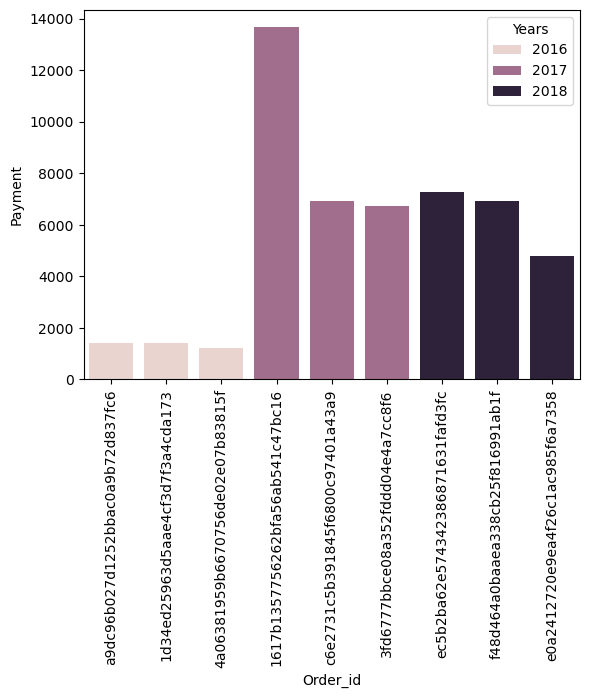

In [46]:
query = """select years, customer_id, payment, d_rank
from 
(select year(orders.order_purchase_timestamp) as years ,
orders.customer_id,
sum(payments.payment_value) as payment,
dense_rank() over(partition by year(orders.order_purchase_timestamp)
order by sum(payments.payment_value) desc) d_rank
from orders join payments
on payments.order_id = orders.order_id
group by year(orders.order_purchase_timestamp),
orders.customer_id) as a 
where d_rank<=3"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data,columns = ["Years", "Order_id", "Payment", "D_Rank"])
sns.barplot(x = "Order_id", y = "Payment", data = df, hue = "Years")
plt.xticks(rotation = 90)
plt.show()